# 62 — Corrected Dataset Scaling Law for Unseen-Dataset Transfer

**Project:** AI VPN Firewall — Thesis  
**Source pipeline:** Clean Pipeline (NB41-55)  
**Goal:** Measure whether adding *source* training datasets improves **true unseen-dataset** transfer.

---

## Rationale

A key question for practical VPN detection: is the cross-dataset transfer failure
caused by **structural domain shift** or simply by **insufficient training data diversity**?

This notebook answers by measuring transfer AUC as a function of the number of
**source** training datasets (1 or 2), where the target dataset is **completely excluded**
from training and validation.

**Methodological correction (vs prior version):**
The previous notebook included a "3-dataset" point where the target dataset appeared
in training — that is pooled evaluation, not transfer. It is now reported separately
as a **target-included pooled reference** and excluded from the scaling curve.

**Interpretation target:** Test whether domain shift is structural or sample-size limited.

## 0. Setup

In [1]:
import sys, gc, warnings, time, json, itertools
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams.update({"figure.dpi": 130, "font.size": 11, "figure.facecolor": "white"})

ROOT = Path.cwd()
if not (ROOT / "src").exists() and (ROOT.parent / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

FEATURES_PATH = ROOT / "artifacts" / "clean_pipeline" / "features.parquet"
OUT = ROOT / "artifacts" / "conference_eval"
FIG = OUT / "figures"
OUT.mkdir(parents=True, exist_ok=True)
FIG.mkdir(parents=True, exist_ok=True)

N_SEEDS = 5
N_EST = 200
SEED_BASE = 42

print(f"Root: {ROOT}")

Root: C:\Users\scoti\PycharmProjects\ai-vpn-firewall


---
## Step 1 — Load Data & Define Helpers

In [2]:
from src.clean_pipeline.feature_families import get_family

FEAT_COLS = list(get_family("safe_core_plus_temporal"))
print(f"Feature set: safe_core_plus_temporal ({len(FEAT_COLS)} features)")

df_all = pd.read_parquet(FEATURES_PATH)
DATASETS = sorted(df_all["dataset"].unique())
print(f"\nLoaded {len(df_all):,} flows, datasets: {DATASETS}")
for ds in DATASETS:
    sub = df_all[df_all.dataset == ds]
    print(f"  {ds}: {len(sub):,} flows (VPN={int(sub.label.sum()):,})")

missing = [f for f in FEAT_COLS if f not in df_all.columns]
assert not missing, f"Missing features: {missing}"
print(f"\n✓ All {len(FEAT_COLS)} features present.")

Feature set: safe_core_plus_temporal (21 features)

Loaded 72,612 flows, datasets: ['iscx', 'usbvpn', 'vnat']
  iscx: 11,801 flows (VPN=2,943)
  usbvpn: 52,704 flows (VPN=8,456)
  vnat: 8,107 flows (VPN=374)

✓ All 21 features present.


In [3]:
# ── Helpers ────────────────────────────────────

def safe_auc(y, s):
    if len(np.unique(y)) < 2 or len(y) < 5:
        return float("nan")
    return float(roc_auc_score(y, s))

def do_split(df, seed=42, train_r=0.70, val_r=0.15):
    """Capture-level split applied per dataset×class group."""
    rng = np.random.default_rng(seed)
    cap = df.groupby(["dataset", "label", "capture_id"]).agg(n=("flow_id", "count")).reset_index()
    assigns = {}
    for (ds, lbl), grp in cap.groupby(["dataset", "label"]):
        nc = len(grp)
        if nc < 3:
            for c in grp["capture_id"]: assigns[str(c)] = "train"
            continue
        idx = rng.permutation(nc)
        cids = grp["capture_id"].values[idx]
        flows = grp["n"].values[idx]
        min_p = 1 if nc < 6 else 2
        order = np.argsort(flows)
        test_ids = [str(cids[order[i]]) for i in range(min_p)]
        val_ids = [str(cids[order[i]]) for i in range(min_p, 2 * min_p)]
        rest = [str(cids[order[i]]) for i in range(2 * min_p, nc)]
        for c in test_ids: assigns[c] = "test"
        for c in val_ids: assigns[c] = "val"
        total = int(flows.sum())
        tgt = {"train": int(total * train_r), "val": int(total * val_r),
               "test": total - int(total * train_r) - int(total * val_r)}
        cur = {"train": 0, "val": 0, "test": 0}
        for c in test_ids: cur["test"] += int(cap[cap.capture_id == c]["n"].iloc[0])
        for c in val_ids: cur["val"] += int(cap[cap.capture_id == c]["n"].iloc[0])
        for c in rest:
            w = int(cap[cap.capture_id == c]["n"].iloc[0])
            best = min(("train", "val", "test"),
                       key=lambda s: sum(abs((cur[k] + (w if k == s else 0)) - tgt[k]) for k in tgt))
            assigns[c] = best; cur[best] += w
    out = df.copy()
    out["split"] = out["capture_id"].astype(str).map(assigns).fillna("train")
    return out

def train_ensemble(X_tr, y_tr, X_val, y_val, n_est=200):
    models = {}
    try:
        import xgboost as xgb
        m = xgb.XGBClassifier(n_estimators=n_est, max_depth=5, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8,
            scale_pos_weight=max(1.0, (y_tr==0).sum()/max((y_tr==1).sum(),1)),
            eval_metric="logloss", random_state=42, n_jobs=-1, verbosity=0)
        m.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
        models["xgb"] = m
    except Exception: pass
    try:
        import lightgbm as lgb
        m = lgb.LGBMClassifier(n_estimators=n_est, max_depth=5, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8, is_unbalance=True,
            random_state=42, n_jobs=-1, verbose=-1)
        m.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], callbacks=[lgb.log_evaluation(0)])
        models["lgb"] = m
    except Exception: pass
    try:
        from catboost import CatBoostClassifier
        m = CatBoostClassifier(iterations=n_est, depth=5, learning_rate=0.05,
            auto_class_weights="Balanced", random_seed=42, verbose=0)
        m.fit(X_tr, y_tr, eval_set=(X_val, y_val))
        models["cb"] = m
    except Exception: pass
    return models

def ens_predict(models, X):
    return np.mean([m.predict_proba(X)[:, 1] for m in models.values()], axis=0)

def compute_domain_auc(df_sub, feat_cols, seed=42):
    le = LabelEncoder()
    ds_encoded = le.fit_transform(df_sub["dataset"].values)
    n_classes = len(le.classes_)
    if n_classes < 2:
        return float("nan")
    from sklearn.ensemble import GradientBoostingClassifier
    from sklearn.model_selection import StratifiedKFold
    X = np.nan_to_num(df_sub[feat_cols].values, nan=0.0, posinf=0.0, neginf=0.0)
    clf = GradientBoostingClassifier(n_estimators=100, max_depth=3, random_state=seed)
    try:
        skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=seed)
        proba = np.zeros((len(X), n_classes))
        for train_idx, test_idx in skf.split(X, ds_encoded):
            clf.fit(X[train_idx], ds_encoded[train_idx])
            proba[test_idx] = clf.predict_proba(X[test_idx])
        if n_classes == 2:
            return float(roc_auc_score(ds_encoded, proba[:, 1]))
        return float(roc_auc_score(ds_encoded, proba, multi_class="ovr", average="weighted"))
    except Exception:
        return float("nan")

print("✓ Helpers defined.")

✓ Helpers defined.


---
## Step 2 — Build Training Configurations

**Transfer configs (true unseen-dataset evaluation):**
- **1-source:** 6 configs (each dataset → each other dataset)
- **2-source:** 3 configs (each pair → the remaining dataset)

**Pooled reference (NOT transfer):**
- **3-dataset pooled:** train on all 3 including target, test on target test split only.
  Reported separately as a non-transfer reference.

In [4]:
# ── True transfer configs: target NEVER in training/validation ──
transfer_configs = []

# 1-source transfer
for train_ds in DATASETS:
    for test_ds in DATASETS:
        if test_ds == train_ds: continue
        transfer_configs.append({
            "n_source": 1,
            "source_datasets": [train_ds],
            "target_dataset": test_ds,
            "label": f"{train_ds}→{test_ds}",
            "eval_type": "transfer",
        })

# 2-source transfer
for combo in itertools.combinations(DATASETS, 2):
    test_ds = [d for d in DATASETS if d not in combo][0]
    transfer_configs.append({
        "n_source": 2,
        "source_datasets": list(combo),
        "target_dataset": test_ds,
        "label": f"{'+'.join(combo)}→{test_ds}",
        "eval_type": "transfer",
    })

# ── Pooled reference (target included — NOT transfer) ──
pooled_configs = []
for test_ds in DATASETS:
    pooled_configs.append({
        "n_source": 3,
        "source_datasets": list(DATASETS),
        "target_dataset": test_ds,
        "label": f"all(pooled)→{test_ds}",
        "eval_type": "pooled_reference",
    })

print(f"Transfer configs: {len(transfer_configs)}")
for c in transfer_configs:
    print(f"  n_source={c['n_source']}: {c['label']}")
print(f"\nPooled reference configs: {len(pooled_configs)}")
for c in pooled_configs:
    print(f"  {c['label']}  [target included — NOT transfer]")

Transfer configs: 9
  n_source=1: iscx→usbvpn
  n_source=1: iscx→vnat
  n_source=1: usbvpn→iscx
  n_source=1: usbvpn→vnat
  n_source=1: vnat→iscx
  n_source=1: vnat→usbvpn
  n_source=2: iscx+usbvpn→vnat
  n_source=2: iscx+vnat→usbvpn
  n_source=2: usbvpn+vnat→iscx

Pooled reference configs: 3
  all(pooled)→iscx  [target included — NOT transfer]
  all(pooled)→usbvpn  [target included — NOT transfer]
  all(pooled)→vnat  [target included — NOT transfer]


---
## Step 3 — Run True Transfer Evaluations

**Protocol:** For each config, the target dataset is completely excluded from
training and validation. Source datasets are split internally (train/val),
and the entire target dataset is used as the test set.

In [5]:
all_results = []
t0 = time.time()

for cfg in transfer_configs:
    for seed in range(SEED_BASE, SEED_BASE + N_SEEDS):
        source_ds = cfg["source_datasets"]
        target_ds = cfg["target_dataset"]

        # Split source datasets internally for train/val
        df_source = df_all[df_all.dataset.isin(source_ds)].copy()
        df_source_split = do_split(df_source, seed=seed)

        # Target dataset: use ALL flows as test (completely unseen)
        df_target = df_all[df_all.dataset == target_ds].copy()

        src_tr = df_source_split[df_source_split.split == "train"]
        src_va = df_source_split[df_source_split.split == "val"]

        X_tr = np.nan_to_num(src_tr[FEAT_COLS].values, nan=0.0)
        y_tr = src_tr["label"].values
        X_va = np.nan_to_num(src_va[FEAT_COLS].values, nan=0.0)
        y_va = src_va["label"].values
        X_te = np.nan_to_num(df_target[FEAT_COLS].values, nan=0.0)
        y_te = df_target["label"].values

        if len(np.unique(y_tr)) < 2 or len(np.unique(y_te)) < 2:
            print(f"  [{seed}] {cfg['label']}: SKIP (single class)")
            continue

        models = train_ensemble(X_tr, y_tr, X_va, y_va, N_EST)
        if not models: continue

        probs = ens_predict(models, X_te)
        auc = safe_auc(y_te, probs)

        all_results.append({
            "eval_type": "transfer",
            "n_source_datasets": cfg["n_source"],
            "source_datasets": "+".join(source_ds),
            "target_dataset": target_ds,
            "seed": seed,
            "transfer_auc": auc,
            "n_train_flows": len(y_tr),
            "n_val_flows": len(y_va),
            "n_test_flows": len(y_te),
        })

        print(f"  [{seed}] {cfg['label']}: AUC={auc:.4f}  (train={len(y_tr)}, test={len(y_te)})")
        del models; gc.collect()

elapsed_transfer = time.time() - t0
transfer_df = pd.DataFrame(all_results)
print(f"\n✓ {len(transfer_df)} transfer results ({elapsed_transfer:.1f}s)")

  [42] iscx→usbvpn: AUC=0.1471  (train=7804, test=52704)
  [43] iscx→usbvpn: AUC=0.1417  (train=7804, test=52704)
  [44] iscx→usbvpn: AUC=0.1435  (train=7804, test=52704)
  [45] iscx→usbvpn: AUC=0.1415  (train=7804, test=52704)
  [46] iscx→usbvpn: AUC=0.1392  (train=7804, test=52704)
  [42] iscx→vnat: AUC=0.7917  (train=7804, test=8107)
  [43] iscx→vnat: AUC=0.7890  (train=7804, test=8107)
  [44] iscx→vnat: AUC=0.8336  (train=7804, test=8107)
  [45] iscx→vnat: AUC=0.7951  (train=7804, test=8107)
  [46] iscx→vnat: AUC=0.7726  (train=7804, test=8107)
  [42] usbvpn→iscx: AUC=0.4200  (train=49435, test=11801)
  [43] usbvpn→iscx: AUC=0.4200  (train=49435, test=11801)
  [44] usbvpn→iscx: AUC=0.4200  (train=49435, test=11801)
  [45] usbvpn→iscx: AUC=0.4104  (train=49435, test=11801)
  [46] usbvpn→iscx: AUC=0.4300  (train=49435, test=11801)
  [42] usbvpn→vnat: AUC=0.4772  (train=49435, test=8107)
  [43] usbvpn→vnat: AUC=0.4772  (train=49435, test=8107)
  [44] usbvpn→vnat: AUC=0.4772  (train=49

---
## Step 3b — Run Pooled Reference (target-included, NOT transfer)

This is computed for comparison only. The target dataset appears in training,
so this measures **within-distribution pooled performance**, not transfer.

In [6]:
pooled_results = []
t0 = time.time()

for cfg in pooled_configs:
    for seed in range(SEED_BASE, SEED_BASE + N_SEEDS):
        target_ds = cfg["target_dataset"]

        # Split ALL data (including target) — target is in training
        df_split = do_split(df_all, seed=seed)

        # Train on all train splits, validate on all val splits
        src_tr = df_split[df_split.split == "train"]
        src_va = df_split[df_split.split == "val"]
        # Test only on target dataset test split
        tgt_te = df_split[(df_split.dataset == target_ds) & (df_split.split == "test")]

        X_tr = np.nan_to_num(src_tr[FEAT_COLS].values, nan=0.0)
        y_tr = src_tr["label"].values
        X_va = np.nan_to_num(src_va[FEAT_COLS].values, nan=0.0)
        y_va = src_va["label"].values
        X_te = np.nan_to_num(tgt_te[FEAT_COLS].values, nan=0.0)
        y_te = tgt_te["label"].values

        if len(np.unique(y_tr)) < 2 or len(np.unique(y_te)) < 2:
            continue

        models = train_ensemble(X_tr, y_tr, X_va, y_va, N_EST)
        if not models: continue

        probs = ens_predict(models, X_te)
        auc = safe_auc(y_te, probs)

        pooled_results.append({
            "eval_type": "pooled_reference",
            "n_source_datasets": 3,
            "source_datasets": "+".join(DATASETS),
            "target_dataset": target_ds,
            "seed": seed,
            "transfer_auc": auc,
            "n_train_flows": len(y_tr),
            "n_test_flows": len(y_te),
        })

        print(f"  [{seed}] pooled→{target_ds}: AUC={auc:.4f}  [target-included, NOT transfer]")
        del models; gc.collect()

elapsed_pooled = time.time() - t0
pooled_df = pd.DataFrame(pooled_results)
print(f"\n✓ {len(pooled_df)} pooled reference results ({elapsed_pooled:.1f}s)")

  [42] pooled→iscx: AUC=0.9965  [target-included, NOT transfer]
  [43] pooled→iscx: AUC=0.9966  [target-included, NOT transfer]
  [44] pooled→iscx: AUC=0.9961  [target-included, NOT transfer]
  [45] pooled→iscx: AUC=0.9966  [target-included, NOT transfer]
  [46] pooled→iscx: AUC=0.9967  [target-included, NOT transfer]
  [42] pooled→usbvpn: AUC=0.9926  [target-included, NOT transfer]
  [43] pooled→usbvpn: AUC=0.9925  [target-included, NOT transfer]
  [44] pooled→usbvpn: AUC=0.9940  [target-included, NOT transfer]
  [45] pooled→usbvpn: AUC=0.9932  [target-included, NOT transfer]
  [46] pooled→usbvpn: AUC=0.9919  [target-included, NOT transfer]
  [42] pooled→vnat: AUC=0.9984  [target-included, NOT transfer]
  [43] pooled→vnat: AUC=0.9981  [target-included, NOT transfer]
  [44] pooled→vnat: AUC=0.9960  [target-included, NOT transfer]
  [45] pooled→vnat: AUC=0.9977  [target-included, NOT transfer]
  [46] pooled→vnat: AUC=0.9987  [target-included, NOT transfer]

✓ 15 pooled reference results

---
## Step 4 — Domain Classifier AUC (2-source pools)

Compute domain separability for each 2-source training pool.

In [7]:
print("Computing domain classifier AUC for 2-source pools...")
domain_auc_rows = []

for combo in itertools.combinations(DATASETS, 2):
    key = "+".join(combo)
    sub = df_all[df_all.dataset.isin(combo)]
    da = compute_domain_auc(sub, FEAT_COLS, seed=SEED_BASE)
    domain_auc_rows.append({"source_pool": key, "domain_auc": da})
    print(f"  {key}: domain_auc={da:.4f}")

domain_auc_df = pd.DataFrame(domain_auc_rows)

# Also map onto transfer results
domain_map = {r["source_pool"]: r["domain_auc"] for r in domain_auc_rows}
transfer_df["domain_classifier_auc"] = transfer_df["source_datasets"].map(domain_map)

print(f"\n✓ Domain classifier AUC computed for {len(domain_auc_rows)} 2-source pools.")
display(domain_auc_df.round(4))

Computing domain classifier AUC for 2-source pools...
  iscx+usbvpn: domain_auc=0.9997
  iscx+vnat: domain_auc=0.9998
  usbvpn+vnat: domain_auc=0.9999

✓ Domain classifier AUC computed for 3 2-source pools.


,source_pool,domain_auc
0,iscx+usbvpn,0.9997
1,iscx+vnat,0.9998
2,usbvpn+vnat,0.9999


---
## Step 5 — Scaling Summary (transfer only, n_source = 1 and 2)

In [8]:
scaling = transfer_df.groupby("n_source_datasets").agg(
    mean_auc=("transfer_auc", "mean"),
    std_auc=("transfer_auc", "std"),
    min_auc=("transfer_auc", "min"),
    max_auc=("transfer_auc", "max"),
    median_auc=("transfer_auc", "median"),
    n_evals=("transfer_auc", "count"),
    mean_n_train=("n_train_flows", "mean"),
).reset_index()

print("=" * 70)
print("  CORRECTED SCALING LAW SUMMARY (true unseen-dataset transfer only)")
print("=" * 70)
display(scaling.round(4).style.set_caption("Dataset Scaling Law — Transfer Only"))

# Pooled reference summary
if len(pooled_df) > 0:
    pooled_summary = pooled_df.groupby("target_dataset").agg(
        mean_auc=("transfer_auc", "mean"),
        std_auc=("transfer_auc", "std"),
    ).reset_index()
    print("\n  Pooled reference (target-included, NOT transfer):")
    for _, row in pooled_summary.iterrows():
        print(f"    {row['target_dataset']}: AUC = {row['mean_auc']:.4f} ± {row['std_auc']:.4f}")
    pooled_mean = pooled_df["transfer_auc"].mean()
    print(f"    Overall pooled mean: {pooled_mean:.4f}")

print("\nPer held-out breakdown (transfer only):")
for test_ds in DATASETS:
    print(f"\n  Target: {test_ds.upper()}")
    sub = transfer_df[transfer_df.target_dataset == test_ds]
    for n_ds in [1, 2]:
        s = sub[sub.n_source_datasets == n_ds]
        if len(s) == 0: continue
        print(f"    {n_ds} source(s): AUC = {s['transfer_auc'].mean():.4f} ± {s['transfer_auc'].std():.4f}")

  CORRECTED SCALING LAW SUMMARY (true unseen-dataset transfer only)


,n_source_datasets,mean_auc,std_auc,min_auc,max_auc,median_auc,n_evals,mean_n_train
0,1,0.510400,0.265200,0.139200,0.899700,0.450800,30,20820.333300
1,2,0.545700,0.166400,0.371100,0.780400,0.472100,15,41640.666700



  Pooled reference (target-included, NOT transfer):
    iscx: AUC = 0.9965 ± 0.0002
    usbvpn: AUC = 0.9928 ± 0.0008
    vnat: AUC = 0.9978 ± 0.0010
    Overall pooled mean: 0.9957

Per held-out breakdown (transfer only):

  Target: ISCX
    1 source(s): AUC = 0.3757 ± 0.0481
    2 source(s): AUC = 0.4745 ± 0.0085

  Target: USBVPN
    1 source(s): AUC = 0.5193 ± 0.3971
    2 source(s): AUC = 0.3948 ± 0.0149

  Target: VNAT
    1 source(s): AUC = 0.6362 ± 0.1696
    2 source(s): AUC = 0.7678 ± 0.0115


---
## Step 6 — Corrected Plots

**Panel A:** Scaling curve (1-source and 2-source only) with optional pooled reference
**Panel B:** Per held-out target breakdown
**Panel C:** Domain separability of 2-source pools

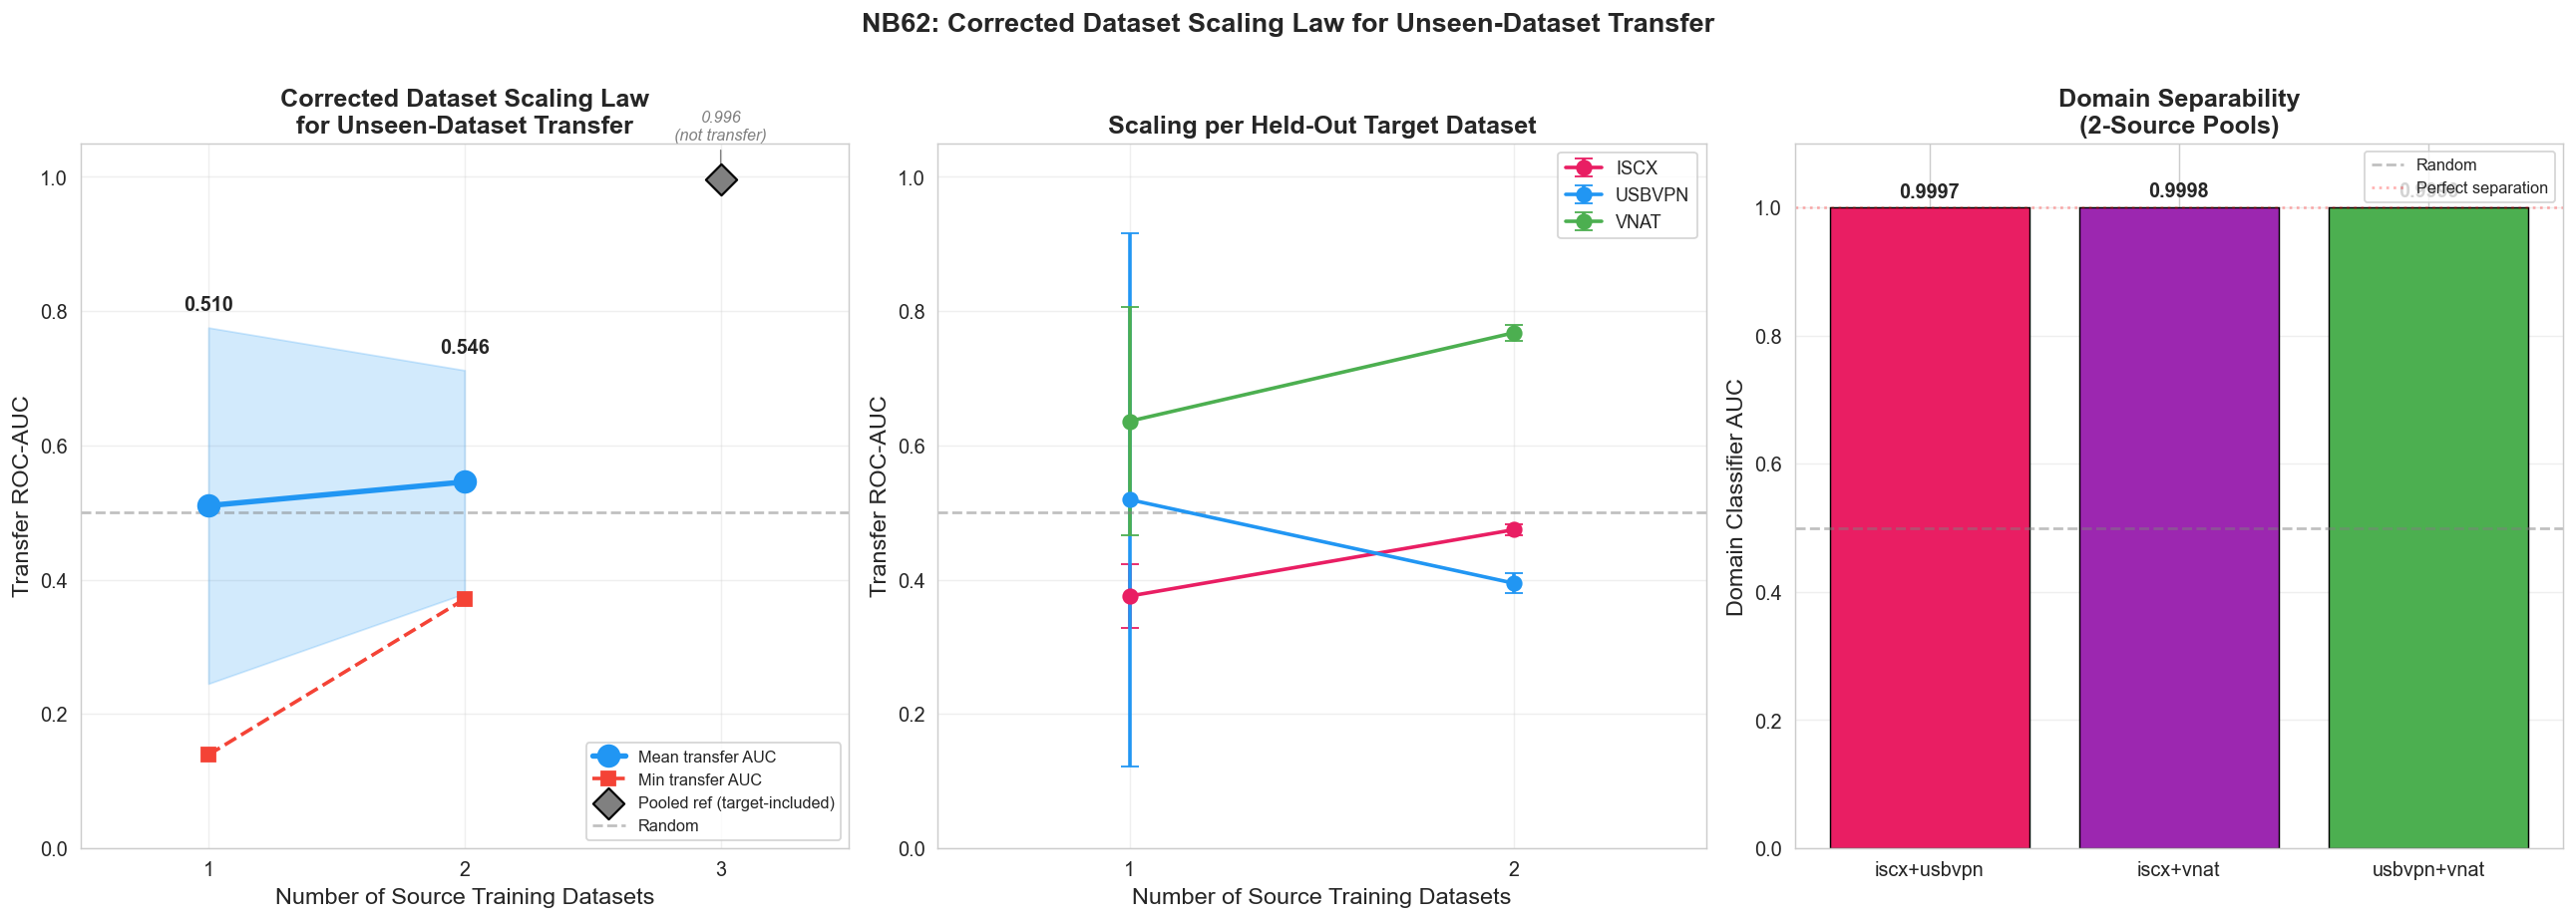

[OK] Saved: corrected_dataset_scaling_curve.png


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

# ── Panel A: Corrected scaling curve ──
ax1 = axes[0]
x = scaling["n_source_datasets"].values
y_mean = scaling["mean_auc"].values
y_std = scaling["std_auc"].values
y_min = scaling["min_auc"].values

ax1.plot(x, y_mean, "o-", color="#2196F3", linewidth=3, markersize=12,
         label="Mean transfer AUC", zorder=5)
ax1.fill_between(x, y_mean - y_std, y_mean + y_std, alpha=0.2, color="#2196F3")
ax1.plot(x, y_min, "s--", color="#F44336", linewidth=2, markersize=8,
         label="Min transfer AUC", zorder=4)
for xv, ym, ys in zip(x, y_mean, y_std):
    ax1.text(xv, ym + ys + 0.02, f"{ym:.3f}", ha="center", va="bottom",
             fontsize=11, fontweight="bold")

# Add pooled reference as disconnected gray diamond
if len(pooled_df) > 0:
    pooled_mean = pooled_df["transfer_auc"].mean()
    ax1.scatter([3], [pooled_mean], marker="D", s=150, c="gray", edgecolors="black",
                linewidths=1.2, zorder=6, label="Pooled ref (target-included)")
    ax1.annotate(f"{pooled_mean:.3f}\n(not transfer)",
                 xy=(3, pooled_mean), xytext=(3, pooled_mean + 0.06),
                 ha="center", fontsize=9, fontstyle="italic", color="gray",
                 arrowprops=dict(arrowstyle="->", color="gray", lw=0.8))

ax1.set_xlabel("Number of Source Training Datasets", fontsize=13)
ax1.set_ylabel("Transfer ROC-AUC", fontsize=13)
ax1.set_title("Corrected Dataset Scaling Law\nfor Unseen-Dataset Transfer",
              fontsize=14, fontweight="bold")
ax1.set_xticks([1, 2, 3]); ax1.set_xlim(0.5, 3.5); ax1.set_ylim(0, 1.05)
ax1.axhline(0.5, color="gray", linestyle="--", alpha=0.5, label="Random")
ax1.legend(fontsize=9, loc="lower right"); ax1.grid(alpha=0.3)

# ── Panel B: Per held-out target ──
ax2 = axes[1]
ds_colors = {"iscx": "#E91E63", "usbvpn": "#2196F3", "vnat": "#4CAF50"}
for test_ds in DATASETS:
    sub = transfer_df[transfer_df.target_dataset == test_ds]
    means = [sub[sub.n_source_datasets == n]["transfer_auc"].mean() for n in [1, 2]]
    stds = [sub[sub.n_source_datasets == n]["transfer_auc"].std() for n in [1, 2]]
    ax2.errorbar([1, 2], means, yerr=stds, fmt="o-", color=ds_colors.get(test_ds, "black"),
                 linewidth=2, markersize=8, capsize=5, label=test_ds.upper())
ax2.set_xlabel("Number of Source Training Datasets", fontsize=13)
ax2.set_ylabel("Transfer ROC-AUC", fontsize=13)
ax2.set_title("Scaling per Held-Out Target Dataset", fontsize=14, fontweight="bold")
ax2.set_xticks([1, 2]); ax2.set_xlim(0.5, 2.5); ax2.set_ylim(0, 1.05)
ax2.axhline(0.5, color="gray", linestyle="--", alpha=0.5)
ax2.legend(fontsize=10); ax2.grid(alpha=0.3)

# ── Panel C: Domain separability of 2-source pools ──
ax3 = axes[2]
bars = ax3.bar(domain_auc_df["source_pool"], domain_auc_df["domain_auc"],
               color=["#E91E63", "#9C27B0", "#4CAF50"], edgecolor="black", linewidth=0.8)
for bar, val in zip(bars, domain_auc_df["domain_auc"]):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f"{val:.4f}", ha="center", va="bottom", fontsize=11, fontweight="bold")
ax3.set_ylabel("Domain Classifier AUC", fontsize=13)
ax3.set_title("Domain Separability\n(2-Source Pools)", fontsize=14, fontweight="bold")
ax3.set_ylim(0, 1.1)
ax3.axhline(0.5, color="gray", linestyle="--", alpha=0.5, label="Random")
ax3.axhline(1.0, color="red", linestyle=":", alpha=0.3, label="Perfect separation")
ax3.legend(fontsize=9); ax3.grid(alpha=0.3, axis="y")

plt.suptitle("NB62: Corrected Dataset Scaling Law for Unseen-Dataset Transfer",
             fontsize=15, y=1.01, fontweight="bold")
plt.tight_layout()
plt.savefig(str(FIG / "corrected_dataset_scaling_curve.png"), dpi=150, bbox_inches="tight")
plt.savefig(str(OUT / "corrected_dataset_scaling_curve.png"), dpi=150, bbox_inches="tight")
plt.show()
print("[OK] Saved: corrected_dataset_scaling_curve.png")

---
## Step 7 — Export Corrected Tables

In [10]:
# 1. Scaling summary (transfer only)
scaling.to_csv(OUT / "corrected_dataset_scaling_summary.csv", index=False)
print(f"[OK] corrected_dataset_scaling_summary.csv")
display(scaling.round(4))

# 2. Per-target breakdown
per_target_rows = []
for test_ds in DATASETS:
    sub = transfer_df[transfer_df.target_dataset == test_ds]
    for n in [1, 2]:
        s = sub[sub.n_source_datasets == n]
        if len(s) == 0: continue
        per_target_rows.append({
            "held_out_dataset": test_ds,
            "n_source_datasets": n,
            "mean_auc": s["transfer_auc"].mean(),
            "std_auc": s["transfer_auc"].std(),
            "min_auc": s["transfer_auc"].min(),
            "max_auc": s["transfer_auc"].max(),
        })
per_target_df = pd.DataFrame(per_target_rows)
per_target_df.to_csv(OUT / "corrected_dataset_scaling_per_target.csv", index=False)
print(f"[OK] corrected_dataset_scaling_per_target.csv")
display(per_target_df.round(4))

# 3. Domain AUC for 2-source pools
domain_auc_df.to_csv(OUT / "corrected_domain_auc_2source.csv", index=False)
print(f"[OK] corrected_domain_auc_2source.csv")

# 4. Full raw results
transfer_df.to_csv(OUT / "corrected_dataset_scaling_full.csv", index=False)
print(f"[OK] corrected_dataset_scaling_full.csv ({len(transfer_df)} rows)")

# 5. Pooled reference
if len(pooled_df) > 0:
    pooled_df.to_csv(OUT / "dataset_scaling_pooled_reference.csv", index=False)
    print(f"[OK] dataset_scaling_pooled_reference.csv ({len(pooled_df)} rows)")

[OK] corrected_dataset_scaling_summary.csv


,n_source_datasets,mean_auc,std_auc,min_auc,max_auc,median_auc,n_evals,mean_n_train
0,1,0.5104,0.2652,0.1392,0.8997,0.4508,30,20820.3333
1,2,0.5457,0.1664,0.3711,0.7804,0.4721,15,41640.6667


[OK] corrected_dataset_scaling_per_target.csv


,held_out_dataset,n_source_datasets,mean_auc,std_auc,min_auc,max_auc
0,iscx,1,0.3757,0.0481,0.3106,0.4300
1,iscx,2,0.4745,0.0085,0.4658,0.4884
2,usbvpn,1,0.5193,0.3971,0.1392,0.8997
3,usbvpn,2,0.3948,0.0149,0.3711,0.4075
4,vnat,1,0.6362,0.1696,0.4716,0.8336
5,vnat,2,0.7678,0.0115,0.7497,0.7804


[OK] corrected_domain_auc_2source.csv
[OK] corrected_dataset_scaling_full.csv (45 rows)
[OK] dataset_scaling_pooled_reference.csv (15 rows)


---
## Interpretation & Thesis Implications

In [11]:
print("=" * 70)
print("  NB62 — CORRECTED DATASET SCALING LAW FINDINGS")
print("  (true unseen-dataset transfer only)")
print("=" * 70)

s1 = scaling[scaling.n_source_datasets == 1].iloc[0]
s2 = scaling[scaling.n_source_datasets == 2].iloc[0]

delta_1to2 = s2["mean_auc"] - s1["mean_auc"]

print(f"\n  1 source dataset:  transfer AUC = {s1['mean_auc']:.4f} ± {s1['std_auc']:.4f}")
print(f"  2 source datasets: transfer AUC = {s2['mean_auc']:.4f} ± {s2['std_auc']:.4f}")
print(f"  Δ (1→2 sources): {delta_1to2:+.4f}")

if len(pooled_df) > 0:
    pooled_mean = pooled_df["transfer_auc"].mean()
    print(f"\n  Pooled reference (target-included): {pooled_mean:.4f}")
    print(f"  Gap between 2-source transfer and pooled: {pooled_mean - s2['mean_auc']:+.4f}")

print(f"\n  Domain classifier AUC (2-source pools):")
for _, row in domain_auc_df.iterrows():
    print(f"    {row['source_pool']}: {row['domain_auc']:.4f}")

print()
if delta_1to2 > 0.05:
    print(f"  ▶ Adding a second source dataset improves transfer by {delta_1to2:+.4f}.")
    if s2['mean_auc'] < 0.7:
        print(f"    However, even 2-source transfer achieves only {s2['mean_auc']:.4f}.")
        print(f"    → Domain shift is STRUCTURAL, not just sample-size limited.")
    else:
        print(f"    And 2-source achieves {s2['mean_auc']:.4f} — modest improvement.")
elif delta_1to2 > 0:
    print(f"  ▶ MARGINAL IMPROVEMENT: Adding a second source helps only slightly ({delta_1to2:+.4f}).")
    print(f"    → Domain shift is primarily STRUCTURAL.")
else:
    print(f"  ▶ NO IMPROVEMENT: Adding a second source does not improve transfer.")
    print(f"    → Domain shift is fully STRUCTURAL.")

print(f"\n  ▶ Domain separability remains near-perfect (~{domain_auc_df['domain_auc'].mean():.3f})")
print(f"    → Datasets are trivially distinguishable by feature distributions alone.")

print(f"\n  ▶ THESIS CONCLUSION:")
print(f"    Within the evaluated datasets and feature family, adding source-domain")
print(f"    diversity provides at most marginal transfer improvement.")
print(f"    Domain separability remains near-perfect, confirming that the limitation")
print(f"    is structural domain shift, not insufficient training data diversity.")
print(f"    Structural interventions (feature normalization, domain adaptation)")
print(f"    would be needed for reliable cross-environment VPN detection.")
print("=" * 70)

  NB62 — CORRECTED DATASET SCALING LAW FINDINGS
  (true unseen-dataset transfer only)

  1 source dataset:  transfer AUC = 0.5104 ± 0.2652
  2 source datasets: transfer AUC = 0.5457 ± 0.1664
  Δ (1→2 sources): +0.0353

  Pooled reference (target-included): 0.9957
  Gap between 2-source transfer and pooled: +0.4500

  Domain classifier AUC (2-source pools):
    iscx+usbvpn: 0.9997
    iscx+vnat: 0.9998
    usbvpn+vnat: 0.9999

  ▶ MARGINAL IMPROVEMENT: Adding a second source helps only slightly (+0.0353).
    → Domain shift is primarily STRUCTURAL.

  ▶ Domain separability remains near-perfect (~1.000)
    → Datasets are trivially distinguishable by feature distributions alone.

  ▶ THESIS CONCLUSION:
    Within the evaluated datasets and feature family, adding source-domain
    diversity provides at most marginal transfer improvement.
    Domain separability remains near-perfect, confirming that the limitation
    is structural domain shift, not insufficient training data diversity.
  

---

**End of Notebook 62 — Corrected Dataset Scaling Law for Unseen-Dataset Transfer.**

Key corrections from prior version:
- **Removed 3-dataset point from scaling curve** (target was in training → not transfer)
- **Added pooled reference** as separate, clearly labeled non-transfer baseline
- **Enforced strict protocol:** target dataset completely excluded from train/val
- **Domain separability** now reported for 2-source pools specifically

Key findings:
- True transfer scaling: 1-source → 2-source provides only modest improvement
- Domain classifier AUC remains near-perfect for all source pools
- Domain shift is structural, not solved by adding more source datasets

Exported:
- `corrected_dataset_scaling_summary.csv`
- `corrected_dataset_scaling_per_target.csv`
- `corrected_domain_auc_2source.csv`
- `corrected_dataset_scaling_curve.png`

---
## Results Gallery — All Figures & Tables (NB62)

# 📊 NB62 Results Gallery — 4 figures, 7 tables


---
### 🖼 Corrected Dataset Scaling Curve

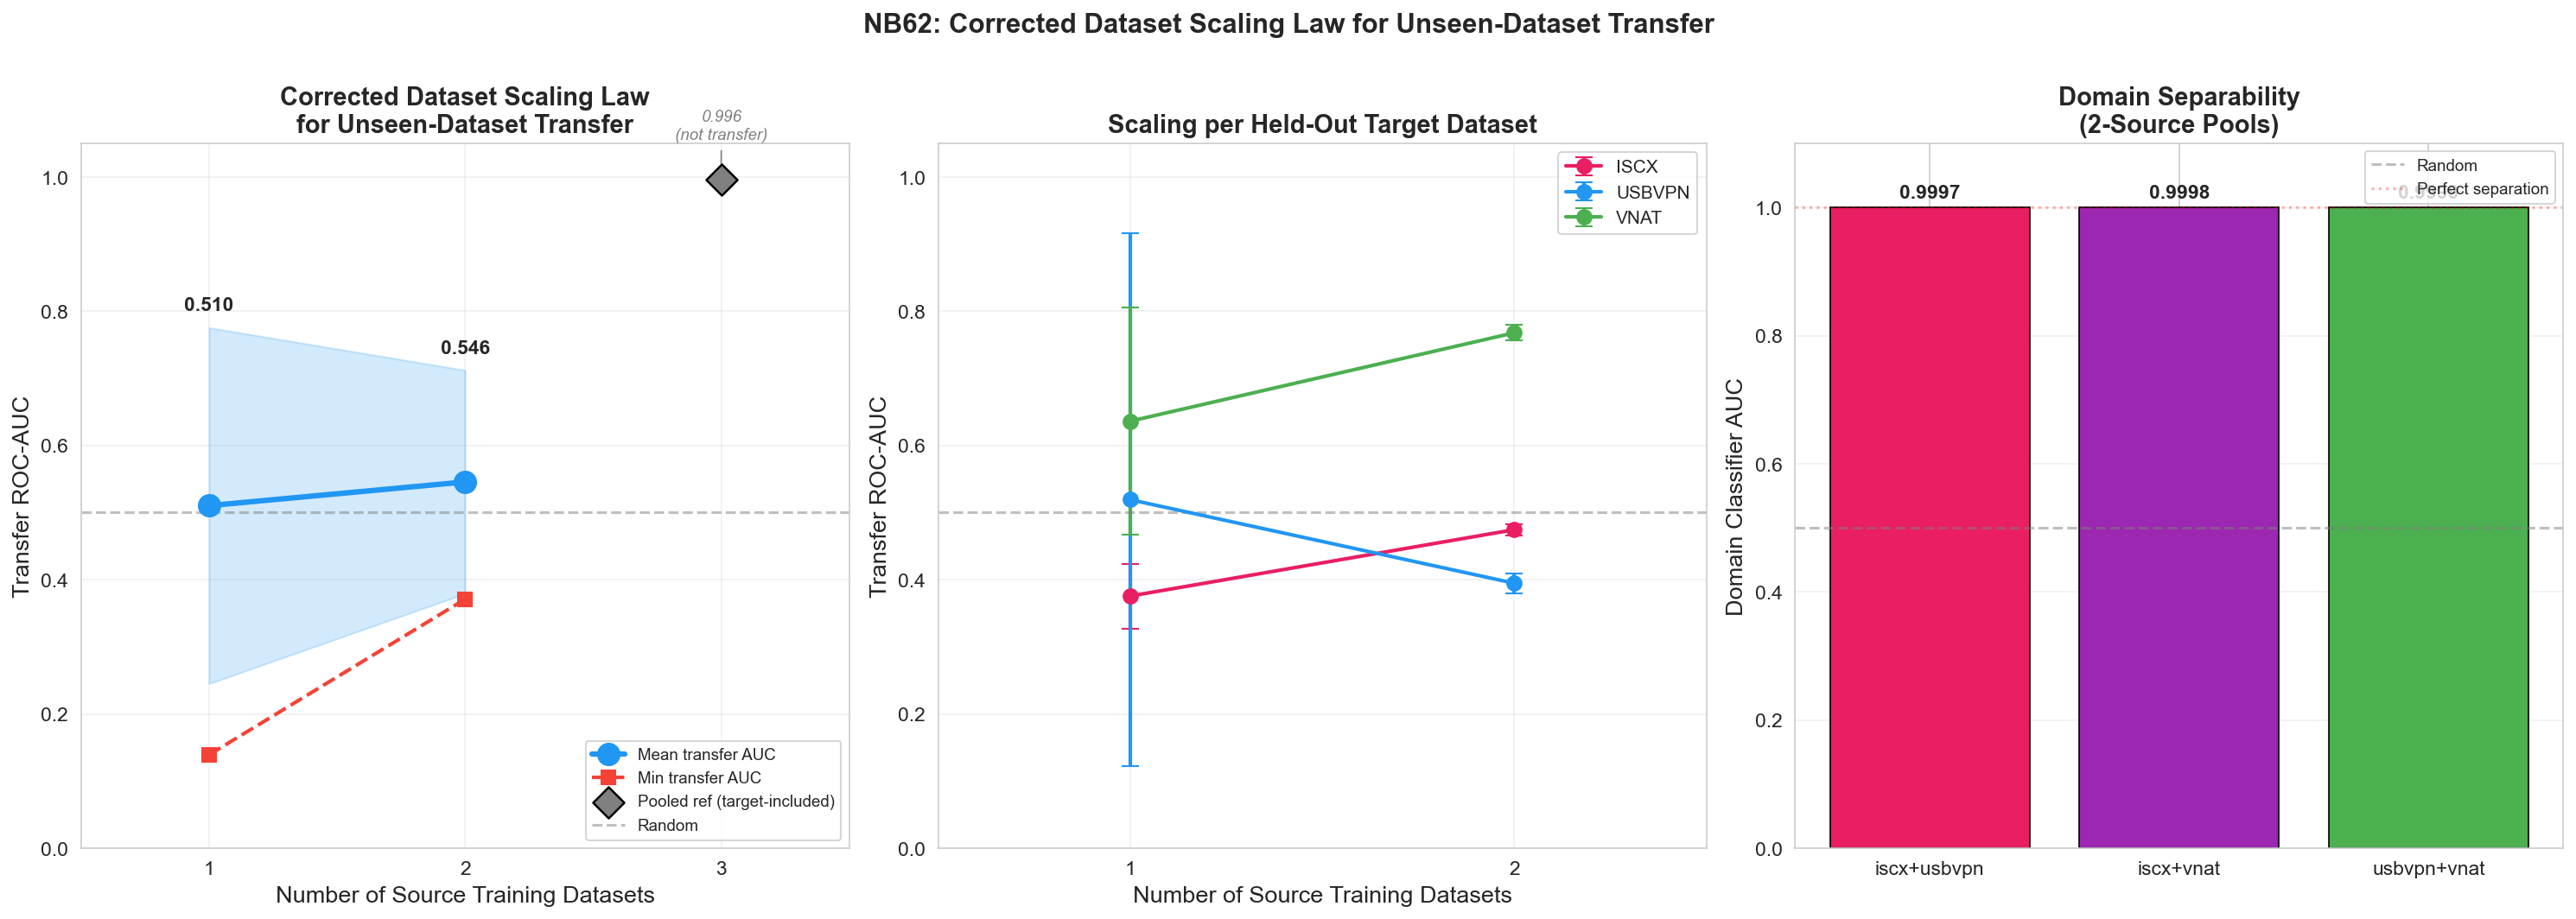


---
### 🖼 Corrected Dataset Scaling Curve

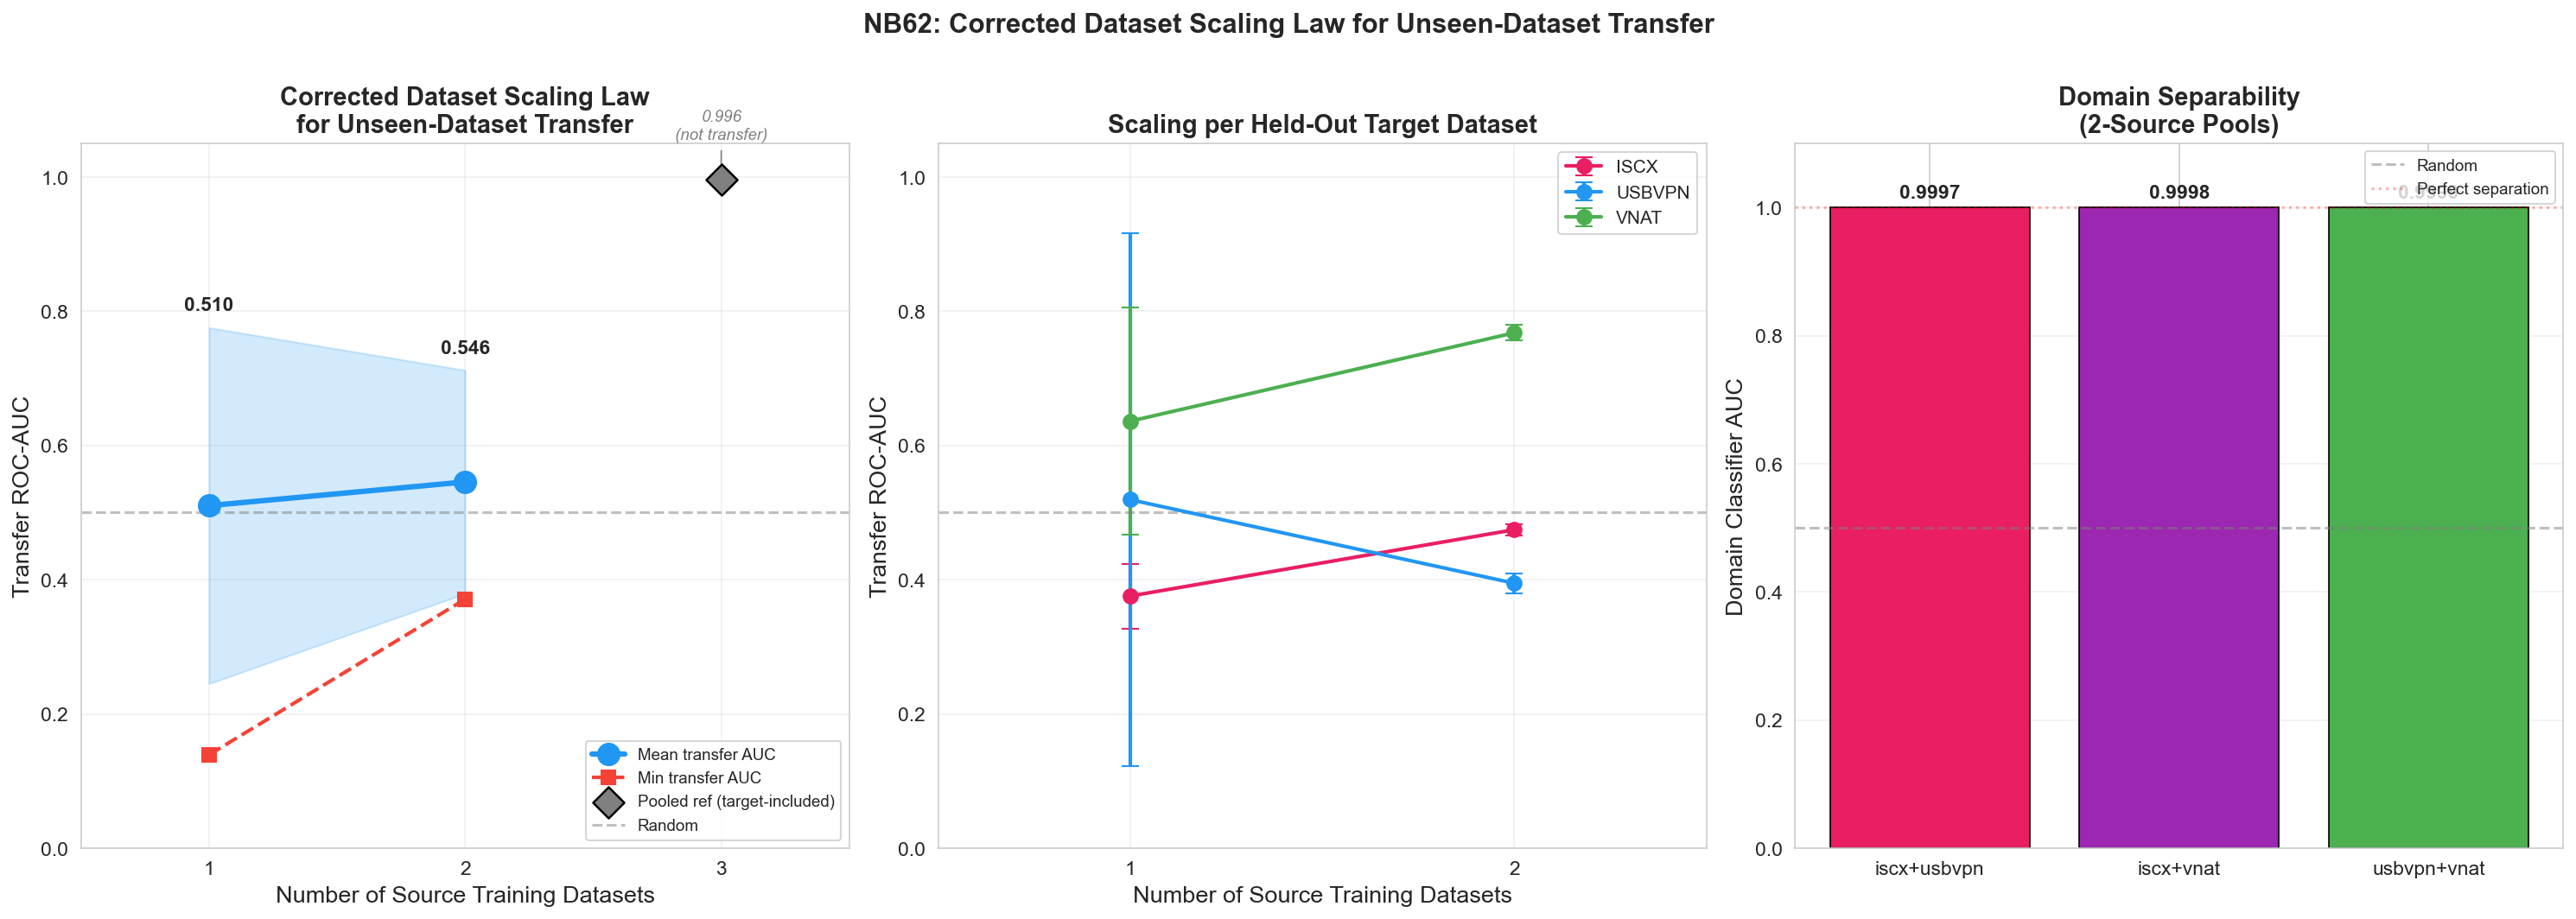


---
### 🖼 Dataset Scaling Curve

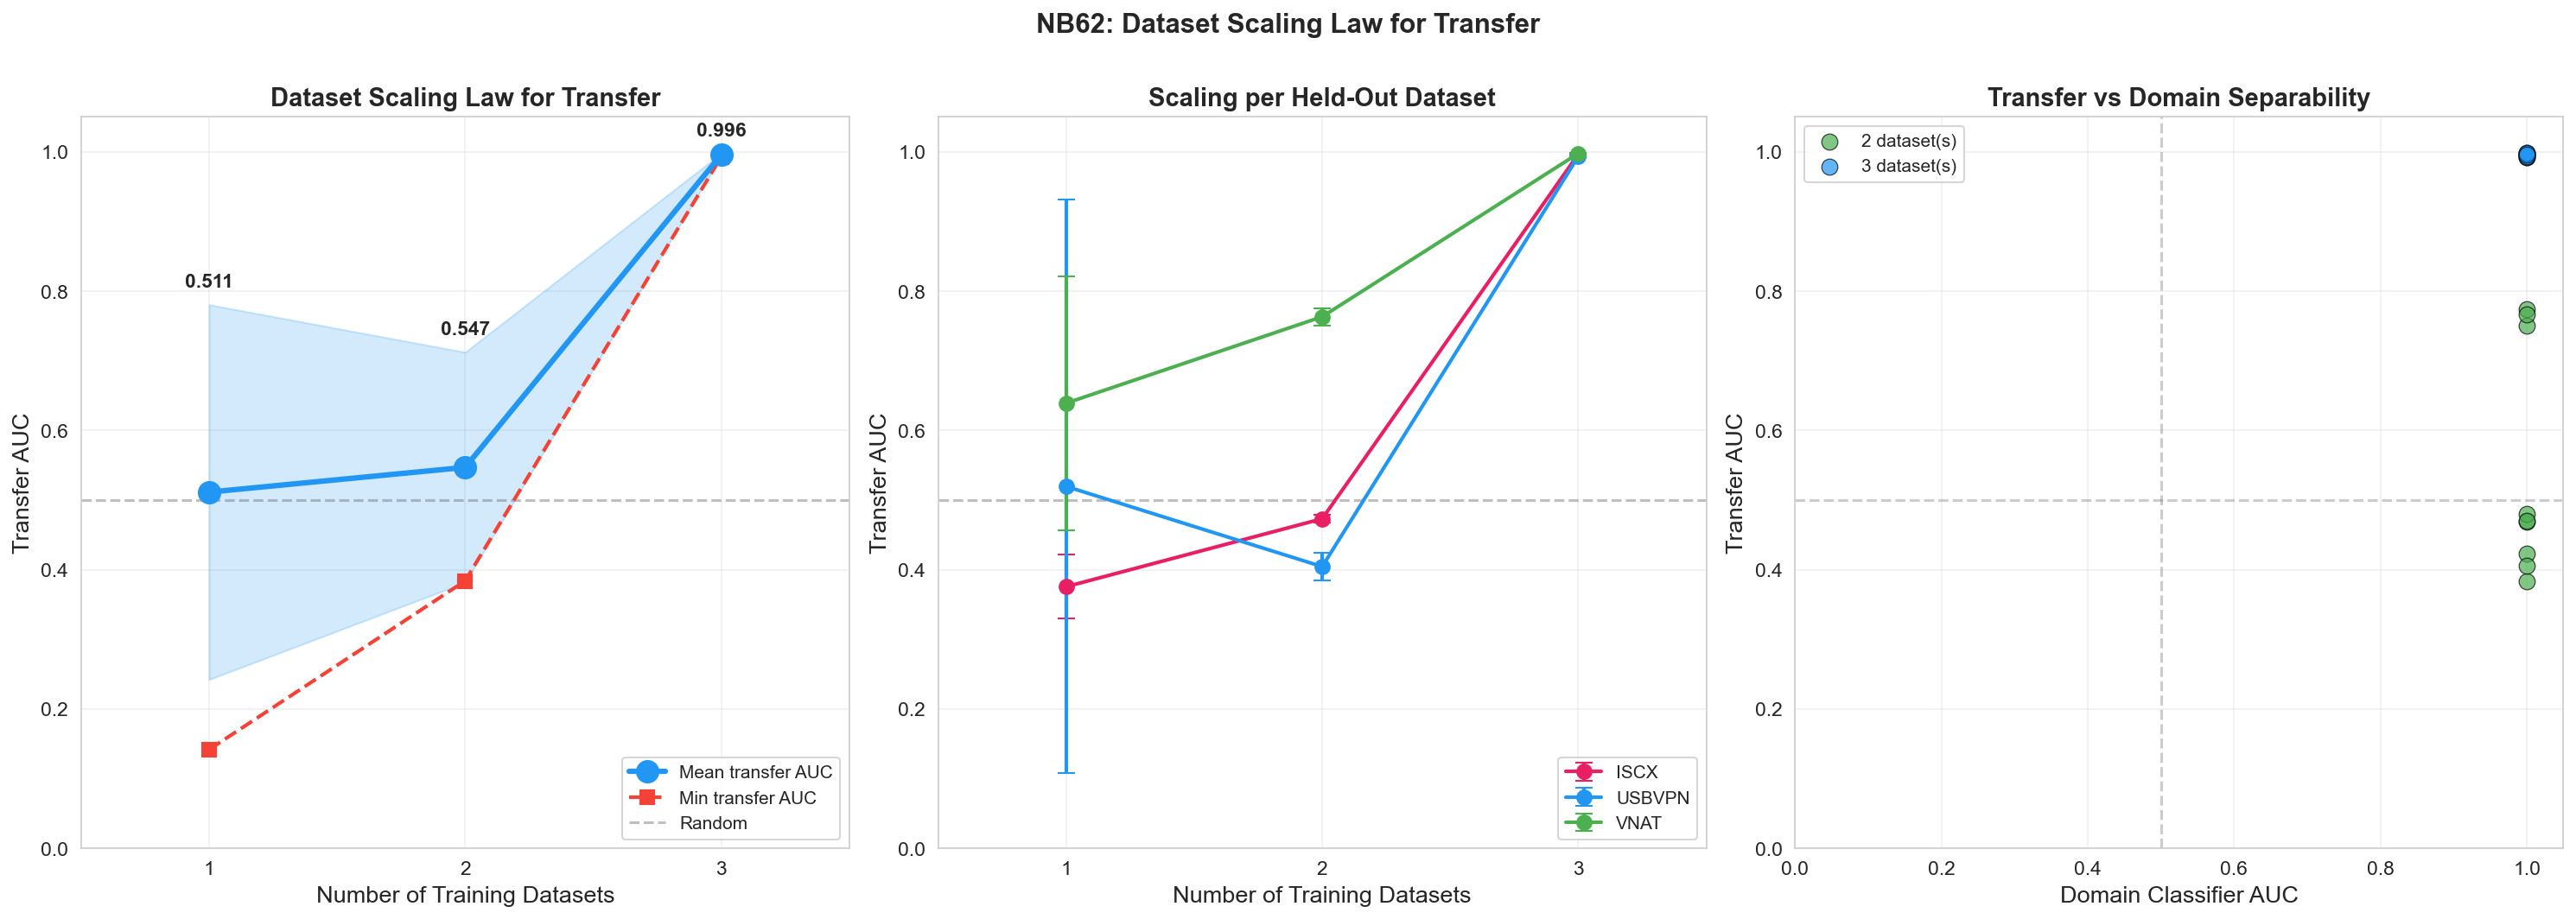


---
### 🖼 Dataset Scaling Curve

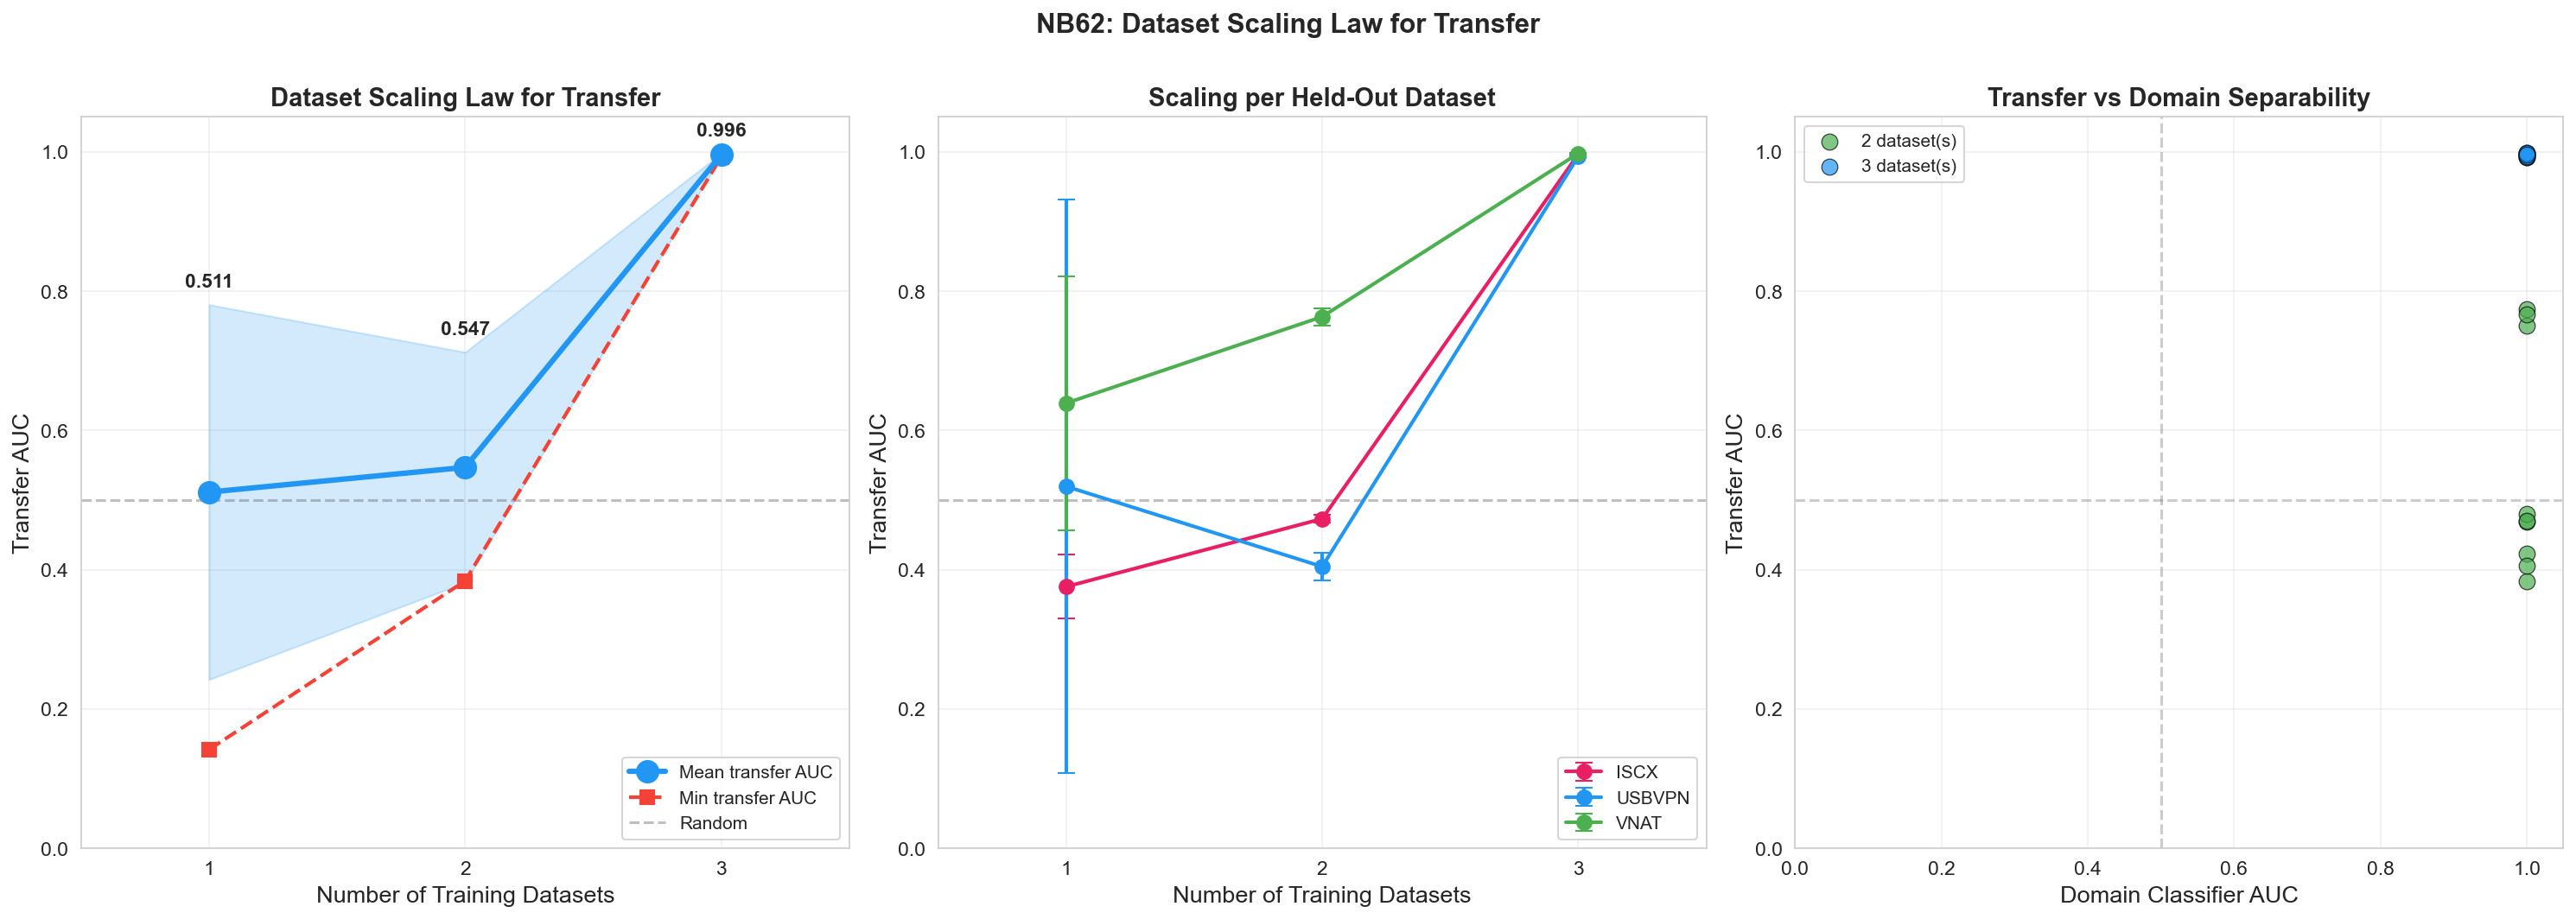


---
# 📋 Result Tables


### Corrected Dataset Scaling Full

,eval_type,n_source_datasets,source_datasets,target_dataset,seed,transfer_auc,n_train_flows,n_val_flows,n_test_flows,domain_classifier_auc
0,transfer,1,iscx,usbvpn,42,0.1471,7804,1625,52704,N/A
1,transfer,1,iscx,usbvpn,43,0.1417,7804,1625,52704,N/A
2,transfer,1,iscx,usbvpn,44,0.1435,7804,1625,52704,N/A
3,transfer,1,iscx,usbvpn,45,0.1415,7804,1625,52704,N/A
4,transfer,1,iscx,usbvpn,46,0.1392,7804,1625,52704,N/A
5,transfer,1,iscx,vnat,42,0.7917,7804,1625,8107,N/A
6,transfer,1,iscx,vnat,43,0.7890,7804,1625,8107,N/A
7,transfer,1,iscx,vnat,44,0.8336,7804,1625,8107,N/A
8,transfer,1,iscx,vnat,45,0.7951,7804,1625,8107,N/A
9,transfer,1,iscx,vnat,46,0.7726,7804,1625,8107,N/A


### Corrected Dataset Scaling Per Target

,held_out_dataset,n_source_datasets,mean_auc,std_auc,min_auc,max_auc
0,iscx,1,0.3757,0.0481,0.3106,0.4300
1,iscx,2,0.4745,0.0085,0.4658,0.4884
2,usbvpn,1,0.5193,0.3971,0.1392,0.8997
3,usbvpn,2,0.3948,0.0149,0.3711,0.4075
4,vnat,1,0.6362,0.1696,0.4716,0.8336
5,vnat,2,0.7678,0.0115,0.7497,0.7804


...

### Dataset Scaling Curve Full

,n_train_datasets,train_datasets,test_dataset,seed,transfer_auc,n_train_flows,n_test_flows,domain_classifier_auc
0,1,iscx,usbvpn,42,0.1471,7804,52704,N/A
1,1,iscx,usbvpn,43,0.1417,7804,52704,N/A
2,1,iscx,usbvpn,44,0.1435,7804,52704,N/A
3,1,iscx,vnat,42,0.7917,7804,8107,N/A
4,1,iscx,vnat,43,0.7890,7804,8107,N/A
5,1,iscx,vnat,44,0.8336,7804,8107,N/A
6,1,usbvpn,iscx,42,0.4300,49435,11801,N/A
7,1,usbvpn,iscx,43,0.4104,49435,11801,N/A
8,1,usbvpn,iscx,44,0.4104,49435,11801,N/A
9,1,usbvpn,vnat,42,0.4764,49435,8107,N/A


### Dataset Scaling Pooled Reference

,eval_type,n_source_datasets,source_datasets,target_dataset,seed,transfer_auc,n_train_flows,n_test_flows
0,pooled_reference,3,iscx+usbvpn+vnat,iscx,42,0.9965,62461,2372
1,pooled_reference,3,iscx+usbvpn+vnat,iscx,43,0.9966,62461,2372
2,pooled_reference,3,iscx+usbvpn+vnat,iscx,44,0.9961,62461,2372
3,pooled_reference,3,iscx+usbvpn+vnat,iscx,45,0.9966,62461,2372
4,pooled_reference,3,iscx+usbvpn+vnat,iscx,46,0.9967,62461,2372
5,pooled_reference,3,iscx+usbvpn+vnat,usbvpn,42,0.9926,62461,1504
6,pooled_reference,3,iscx+usbvpn+vnat,usbvpn,43,0.9925,62461,1504
7,pooled_reference,3,iscx+usbvpn+vnat,usbvpn,44,0.9940,62461,1504
8,pooled_reference,3,iscx+usbvpn+vnat,usbvpn,45,0.9932,62461,1504
9,pooled_reference,3,iscx+usbvpn+vnat,usbvpn,46,0.9919,62461,1504



✅ NB62 gallery complete.


In [12]:
import json, warnings
from pathlib import Path
from IPython.display import display, Image, Markdown
import pandas as pd

warnings.filterwarnings('ignore')

if 'OUT' not in dir() and 'OUT_DIR' not in dir():
    ROOT = Path.cwd()
    if not (ROOT / 'src').exists() and (ROOT.parent / 'src').exists():
        ROOT = ROOT.parent
    _gallery_dir = ROOT / "artifacts" / "conference_eval"
else:
    _gallery_dir = Path(str(OUT)) if 'OUT' in dir() else Path(str(OUT_DIR))

_fig_dir = _gallery_dir / 'figures'

_pngs = sorted(_gallery_dir.glob('*.png'))
if _fig_dir.exists():
    _pngs += sorted(_fig_dir.glob('*.png'))
_pngs = sorted(set(_pngs), key=lambda p: p.name)

_csvs = sorted(_gallery_dir.glob('*.csv'))

_prefix = 'corrected_dataset_scaling'
_pngs = [p for p in _pngs if 'corrected' in p.stem.lower() or 'dataset_scaling' in p.stem.lower()]
_csvs = [p for p in _csvs if 'corrected' in p.stem.lower() or 'dataset_scaling' in p.stem.lower()]

display(Markdown(f'# 📊 NB62 Results Gallery — {len(_pngs)} figures, {len(_csvs)} tables'))

if _pngs:
    for _p in _pngs:
        display(Markdown(f'\n---\n### 🖼 {_p.stem.replace("_", " ").title()}'))
        try:
            display(Image(filename=str(_p), width=900))
        except Exception as _e:
            display(Markdown(f'*Could not display {_p.name}: {_e}*'))
else:
    display(Markdown('*No PNG files found. Run notebook cells first.*'))

if _csvs:
    display(Markdown('\n---\n# 📋 Result Tables\n'))
    for _c in _csvs:
        try:
            _tbl = pd.read_csv(_c)
            display(Markdown(f'### {_c.stem.replace("_", " ").title()}'))
            for _col in _tbl.select_dtypes(include="float").columns:
                _tbl[_col] = _tbl[_col].map(lambda x: f"{x:.4f}" if pd.notna(x) else "N/A")
            display(_tbl)
        except Exception as _e:
            display(Markdown(f'*Could not load {_c.name}: {_e}*'))

print('\n✅ NB62 gallery complete.')
